# EDA - Default of Credit Card Clients

This notebook contains the **exploratory data analysis (EDA) and classification modeling** performed on the **Default of Credit Card Clients** dataset.  

Dataset source: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

---

## Goal

The goal of this project is to **analyze and model credit card default payments**, including:  
1. **Exploratory Data Analysis (EDA)** – understand data distribution, patterns, and correlations.  
2. **Feature Engineering** – create, transform, or select features for better predictive performance.  
3. **Model Training** – build classification models to predict default payments.  
4. **Model Evaluation** – assess model performance using appropriate metrics and validate results.  


---

## Overview

This research focuses on the **case of customers' default payments in Taiwan** and compares the predictive accuracy of the probability of default among six data mining methods.

### Dataset Characteristics
- **Type:** Multivariate  
- **Subject Area:** Business  
- **Associated Task:** Classification  
- **Feature Type:** Integer, Real  
- **Instances:** 30,000  
- **Features:** 23  

### Analysis Includes
- Basic data information
- Class distribution
- Numeric summaries
- Histograms
- Correlation matrices
- Boxplots for key features
- Sampled scatter matrix

In [3]:
# Core libraries
import re

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & feature engineering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate

# Metrics & evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score, confusion_matrix, 
                             classification_report)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier



import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../resource/source/UCI_Credit_Card.csv")
# read dataset

In [5]:
print("Rows X Columns:",df.shape)
print("Source Columns:",df.columns.tolist())
df.head(2)

Rows X Columns: (30000, 25)
Source Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1


In [6]:
df.drop('ID',axis=1,inplace=True)
# remove ID columns

In [7]:
df.rename(columns={'default.payment.next.month':'default_payment_next_month'}, inplace=True)
# rename target column

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

In [10]:
# high level dataset details
pd.DataFrame(
    {
    "data_type": df.dtypes.astype(str),
     "n_unique": df.nunique(),
      "missing_values": df.isna().sum()
    })

,data_type,n_unique,missing_values
LIMIT_BAL,float64,81,0
SEX,int64,2,0
EDUCATION,int64,7,0
MARRIAGE,int64,4,0
AGE,int64,56,0
PAY_0,int64,11,0
PAY_2,int64,11,0
PAY_3,int64,11,0
PAY_4,int64,11,0
PAY_5,int64,10,0


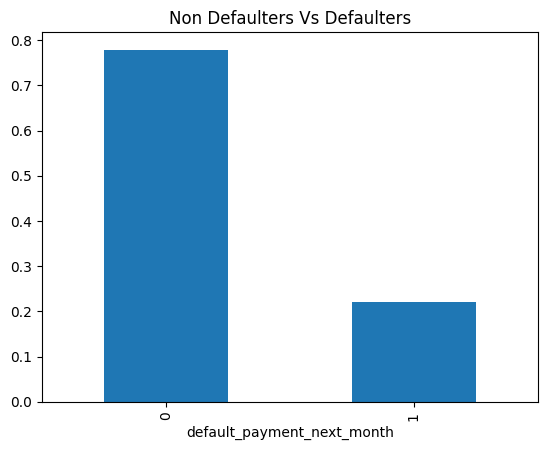

In [11]:
df['default_payment_next_month'].value_counts(normalize=True).plot.bar()
plt.title('Non Defaulters Vs Defaulters')
plt.show()

In [12]:
target = "default_payment_next_month"
# target column value assign

In [13]:
# Count of each value
counts = df[target].value_counts()
print("Counts:", counts)

Counts: default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64


In [14]:
# Percentage of each value
percentages = df[target].value_counts(normalize=True) * 100
print("Percentages:", percentages)

Percentages: default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64


#### Default = 22%
#### Imbalanced Data

##### SEX EDUCATION MARRIAGE
    1. SEX: Gender (1=male, 2=female)
    2. EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
    3. MARRIAGE: Marital status (1=married, 2=single, 3=others)

In [15]:
df[['SEX','EDUCATION','MARRIAGE']].describe()

,SEX,EDUCATION,MARRIAGE
count,30000.000000,30000.000000,30000.000000
mean,1.603733,1.853133,1.551867
std,0.489129,0.790349,0.521970
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000
75%,2.000000,2.000000,2.000000
max,2.000000,6.000000,3.000000


In [16]:
print(df['MARRIAGE'].unique())
print(df['MARRIAGE'].value_counts())

[1 2 3 0]
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [17]:
# Replacing 0 of marriage with 3(others)
df['MARRIAGE']=df['MARRIAGE'].replace({0:3})

In [18]:
print(df['EDUCATION'].unique())
print(df['EDUCATION'].value_counts())

[2 1 3 5 4 6 0]
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


In [19]:
# Replacing 0,5,6 with 4
df['EDUCATION']=df['EDUCATION'].replace({0:4,5:4,6:4})

In [20]:
print(df['SEX'].unique())
print(df['SEX'].value_counts())

[2 1]
SEX
2    18112
1    11888
Name: count, dtype: int64


In [21]:
df['MARRIAGE']=df['MARRIAGE'].replace({1:'married',2:'single',3:'others'})
df['EDUCATION']=df['EDUCATION'].replace({1:'graduate school',2:'university',3:'high school',4:'others'})
df['SEX']=df['SEX'].replace({1:'male', 2:'female'})

In [22]:
df.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000.0,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [23]:
def plot_categoric(cat_col):
    plt.title('{0} vs DEFAULT PROBABILITY'.format(cat_col))
    df.groupby(cat_col)[target].mean().plot.bar()
    plt.show()

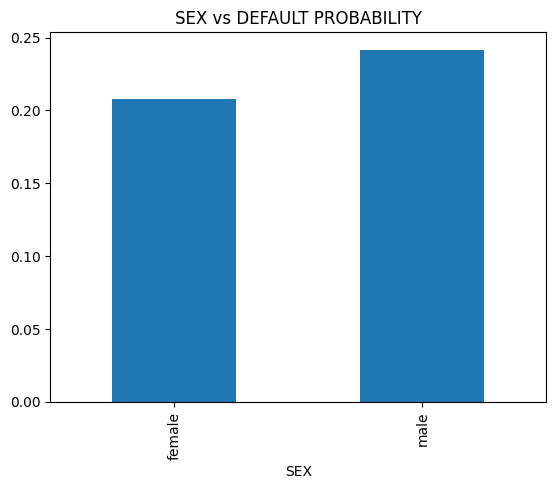

In [24]:
plot_categoric('SEX')

 ###  Men most like to be defaulters compared to Females

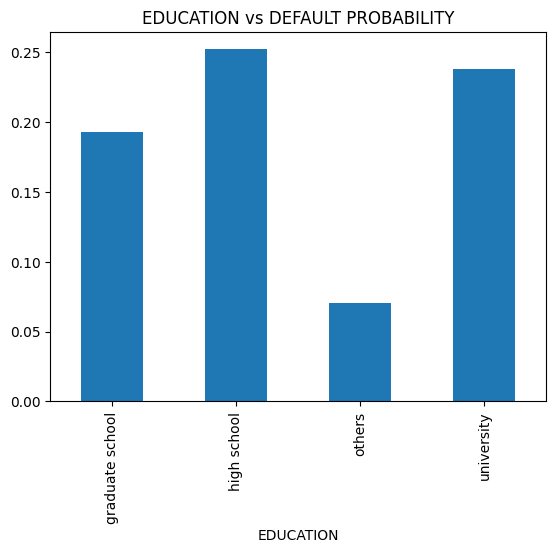

In [25]:
plot_categoric('EDUCATION')

### High School > University > graduates with respect to defaulters

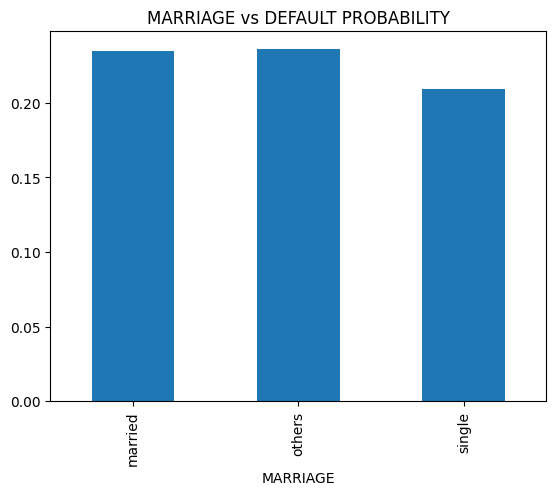

In [26]:
plot_categoric('MARRIAGE')

In [27]:
#

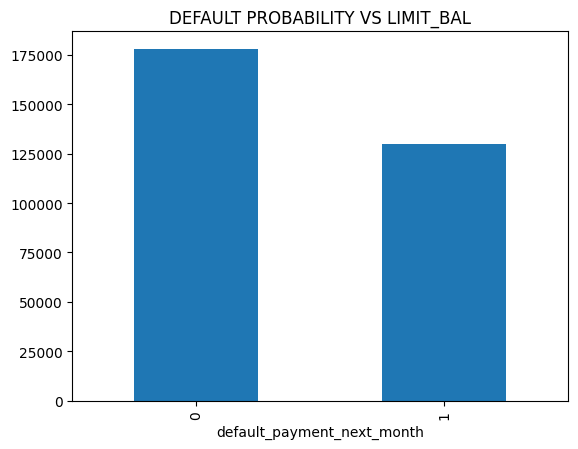

In [28]:
plt.title('DEFAULT PROBABILITY VS {0}'.format('LIMIT_BAL'))
df.groupby(target)['LIMIT_BAL'].mean().plot.bar()
plt.show()

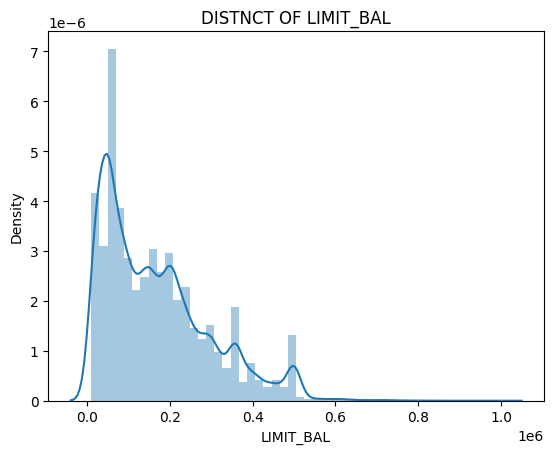

In [29]:
sns.distplot(df['LIMIT_BAL'])
plt.title('DISTNCT OF LIMIT_BAL')
plt.show()

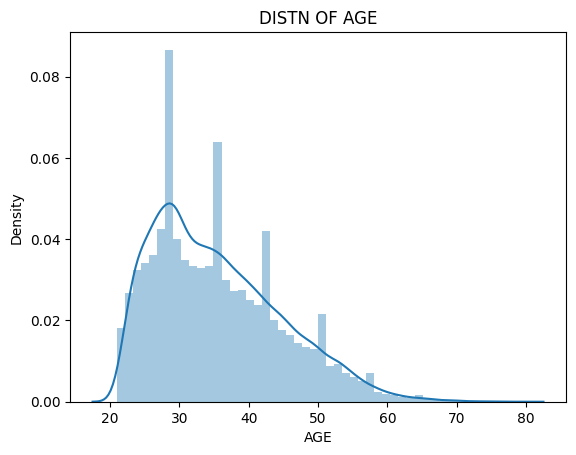

In [30]:
sns.distplot(df['AGE'])
plt.title('DISTN OF AGE')
plt.show()

# ANALYSING NUMERIC FEATURES FOR OUTLIERS

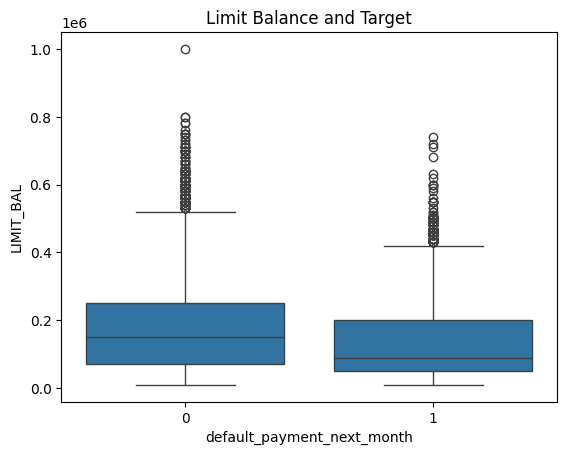

In [32]:
sns.boxplot(x=df[target],y=df['LIMIT_BAL'],data=df)
plt.title('Limit Balance and Target')
plt.show()

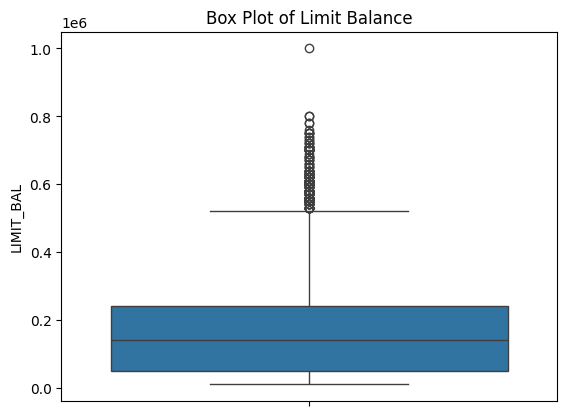

In [33]:
sns.boxplot(df['LIMIT_BAL'])
plt.title('Box Plot of Limit Balance')
plt.show()

In [34]:
df['LIMIT_BAL'].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

In [35]:
df.loc[df['LIMIT_BAL']>=df['LIMIT_BAL'].quantile(0.95),'LIMIT_BAL']=df['LIMIT_BAL'].quantile(0.95)

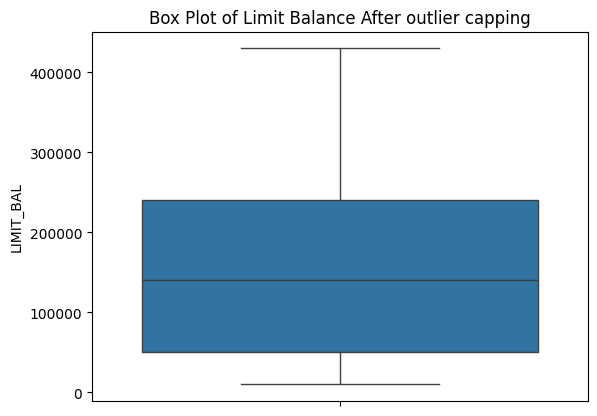

In [37]:
sns.boxplot(df['LIMIT_BAL'])
plt.title('Box Plot of Limit Balance After outlier capping')
plt.show()

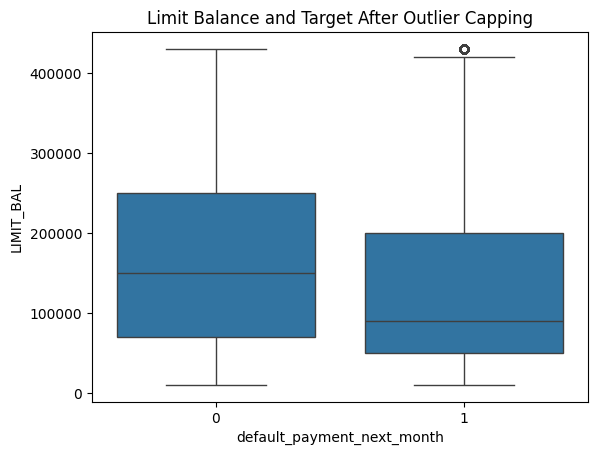

In [38]:
sns.boxplot(x=df[target],y=df['LIMIT_BAL'],data=df)
plt.title('Limit Balance and Target After Outlier Capping')
plt.show()

In [39]:
df[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


In [45]:
for i in range(1,7):
    feature='BILL_AMT'+str(i)
    df[feature]=df[feature].apply(lambda x:abs(x))

In [46]:
df[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51268.752900,49233.960900,4.707718e+04,43336.354900,40382.783233,39012.777133
std,73604.241808,71135.811734,6.930594e+04,64283.429153,60749.763983,59461.822503
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,3593.500000,3051.500000,2.776000e+03,2400.000000,1865.000000,1359.000000
50%,22385.500000,21231.500000,2.010450e+04,19068.000000,18126.500000,17130.000000
75%,67124.750000,64022.500000,6.017775e+04,54558.500000,50218.250000,49251.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


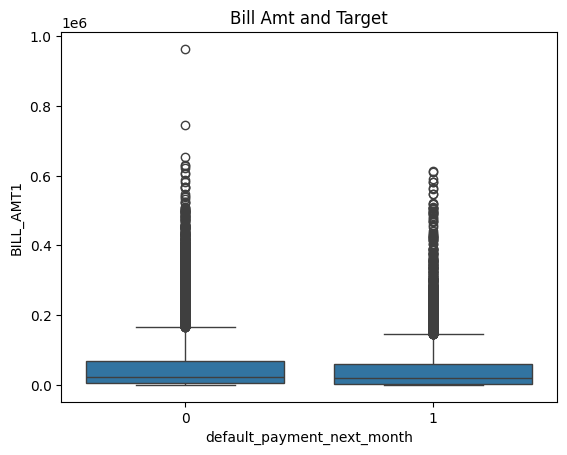

In [48]:
sns.boxplot(x=df[target],y=df['BILL_AMT1'],data=df)
plt.title('Bill Amt and Target')
plt.show()

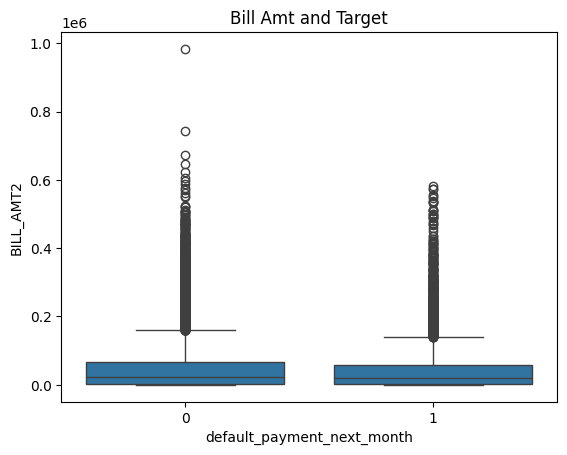

In [50]:
sns.boxplot(x=df[target],y=df['BILL_AMT2'],data=df)
plt.title('Bill Amt and Target')
plt.show()

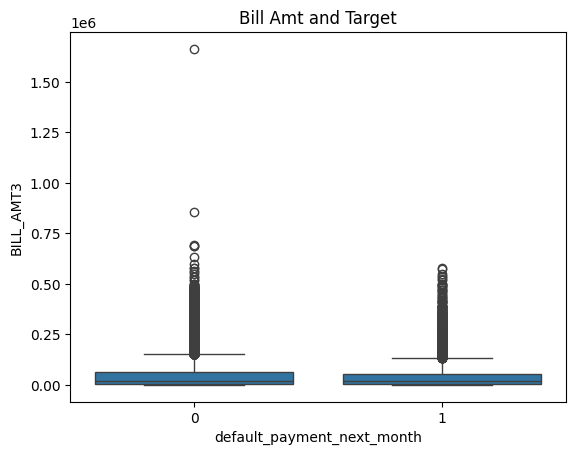

In [51]:
sns.boxplot(x=df[target],y=df['BILL_AMT3'],data=df)
plt.title('Bill Amt and Target')
plt.show()

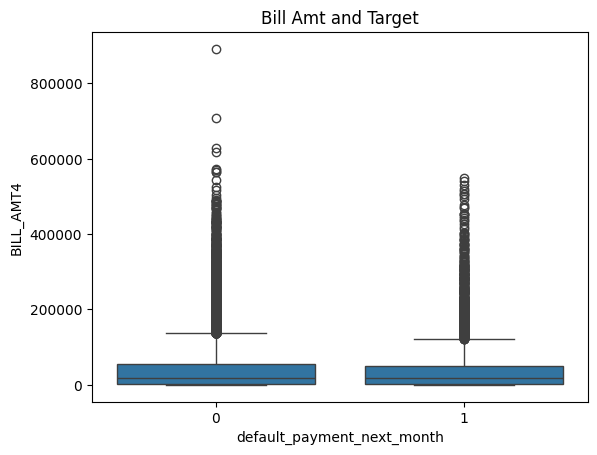

In [52]:
sns.boxplot(x=df[target],y=df['BILL_AMT4'],data=df)
plt.title('Bill Amt and Target')
plt.show()

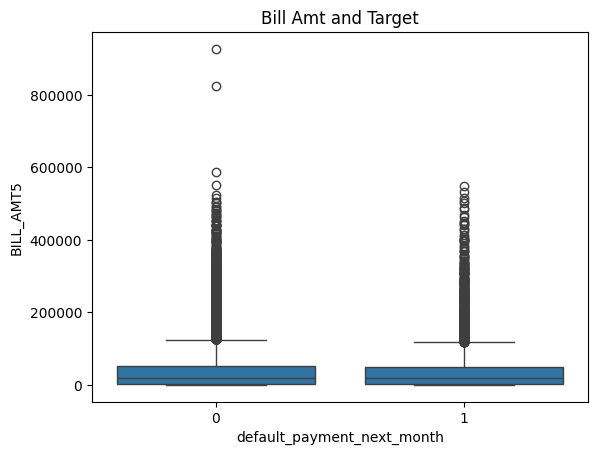

In [53]:
sns.boxplot(x=df[target],y=df['BILL_AMT5'],data=df)
plt.title('Bill Amt and Target')
plt.show()

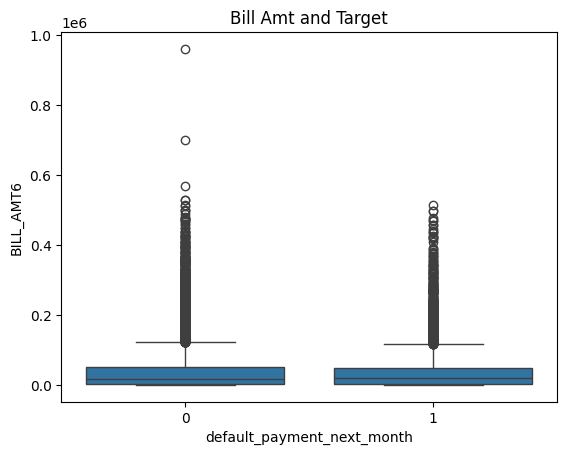

In [54]:
sns.boxplot(x=df[target],y=df['BILL_AMT6'],data=df)
plt.title('Bill Amt and Target')
plt.show()

In [55]:
def cap_upper(df,feature,limit):
    percentile_limit=df[feature].quantile(limit)
    df.loc[df[feature]>=percentile_limit,feature]=percentile_limit
    return df[feature]

In [59]:
for i in range(1,7):
    feature='BILL_AMT'+str(i)
    df[feature]=cap_upper(df,feature,limit=0.95)

In [65]:
def boxplot(feature):
    sns.boxplot(x=df[target],y=df[feature],data=df)
    plt.title(f"{feature} and Target")
    plt.show()

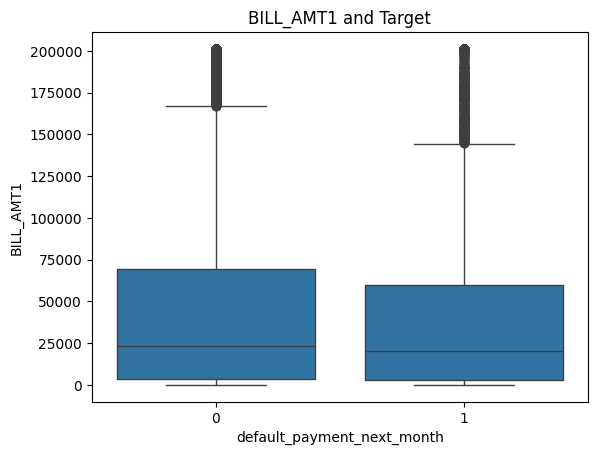

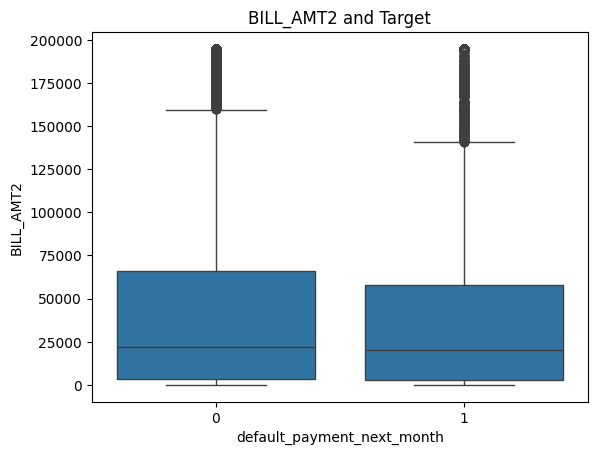

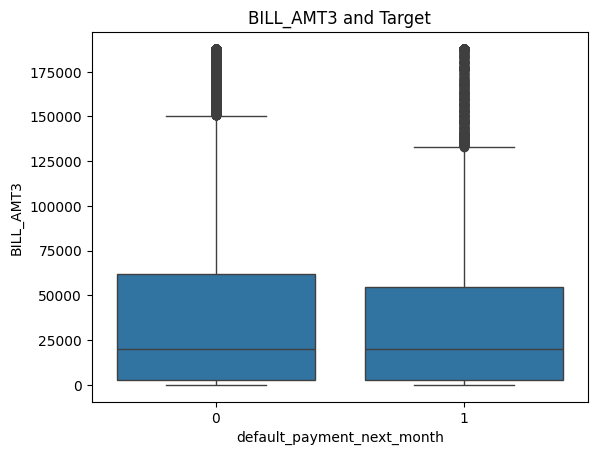

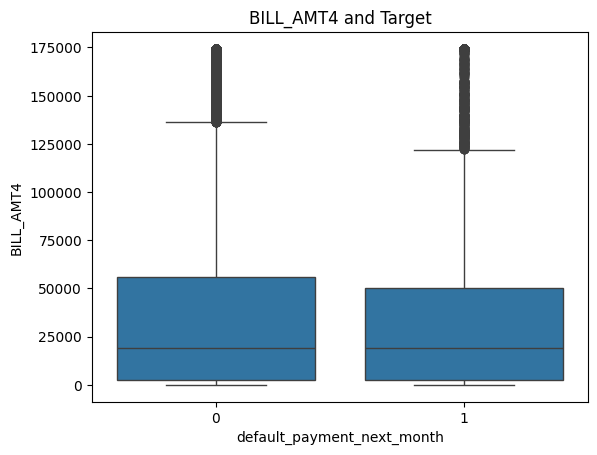

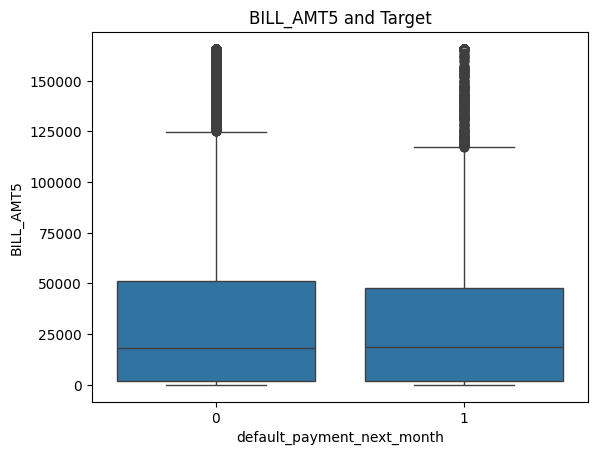

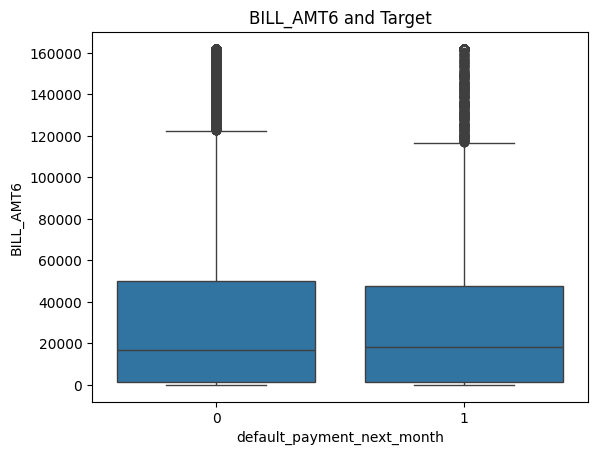

In [66]:
for feature in ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']:
    boxplot(feature)

In [67]:
df[['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']].describe(percentiles=[0.25,0.5,0.75,0.8,0.85,0.9,0.95,0.98])

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
80%,6192.200000,6.000000e+03,5284.00000,5000.000000,5000.000000,5000.000000
85%,8000.000000,7.956150e+03,7000.00000,6300.000000,6271.300000,6200.000000
90%,10300.000000,1.040110e+04,10000.00000,9570.600000,9500.000000,9600.000000


In [68]:
def outelierplot(feature):
    sns.boxplot(x=df[target],y=df[feature],data=df)
    plt.title(f'{feature} and Target Before Outlier Treatment')
    plt.show()

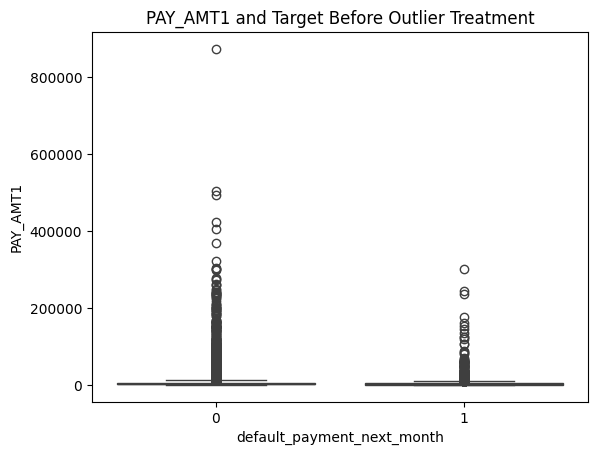

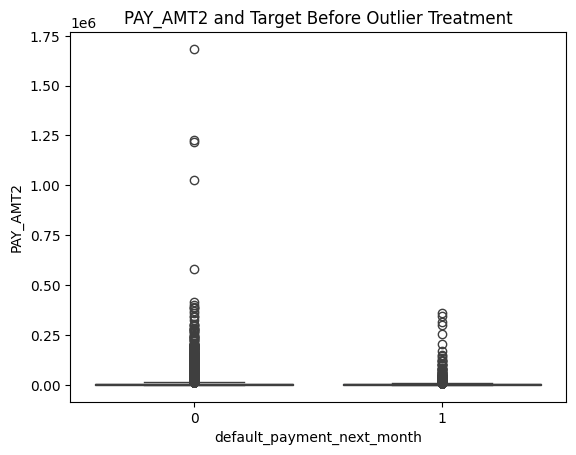

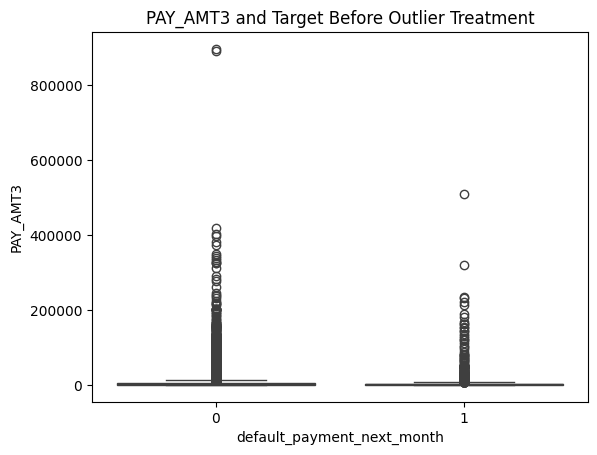

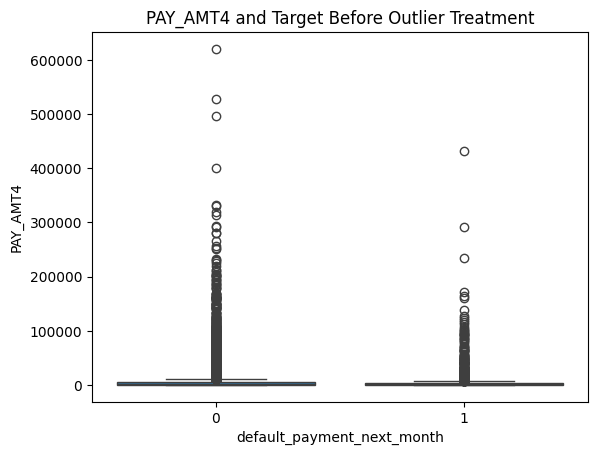

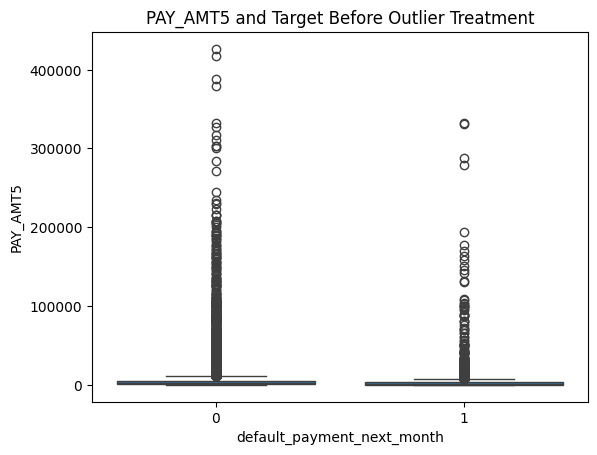

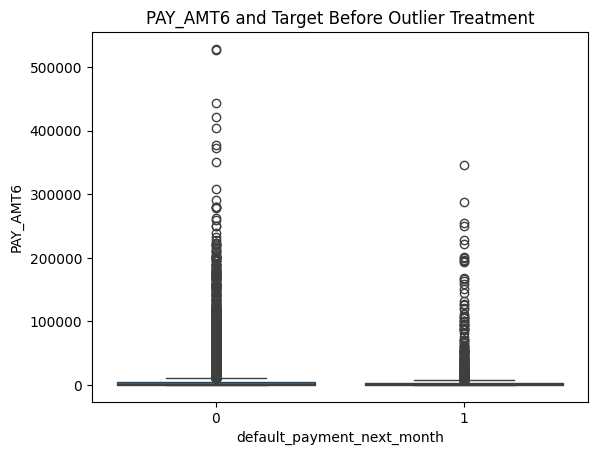

In [70]:
for f in ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']:
    outelierplot(f)

In [71]:
for i in range(1,7):
    feature='PAY_AMT'+str(i)
    df[feature]=cap_upper(df,feature,limit=0.90)

In [72]:
def treatment(feature):
    sns.boxplot(x=df[target],y=df[feature],data=df)
    plt.title(f'{feature} and Target After Outlier Treatment')
    plt.show()

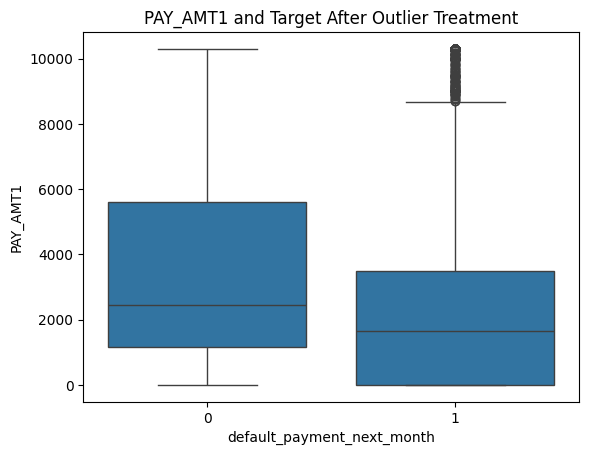

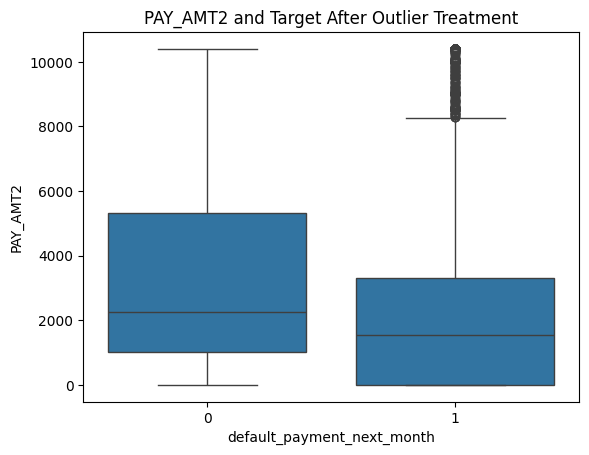

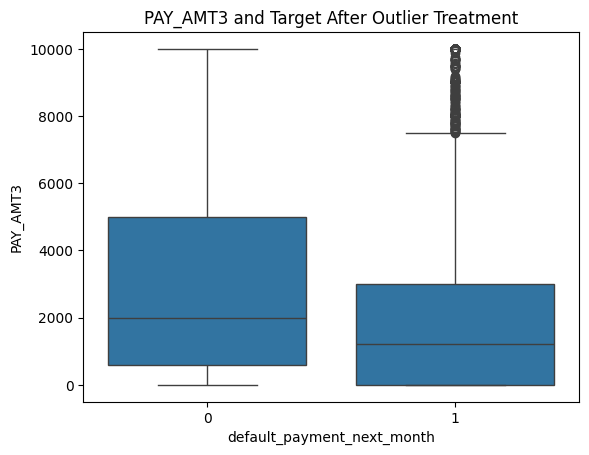

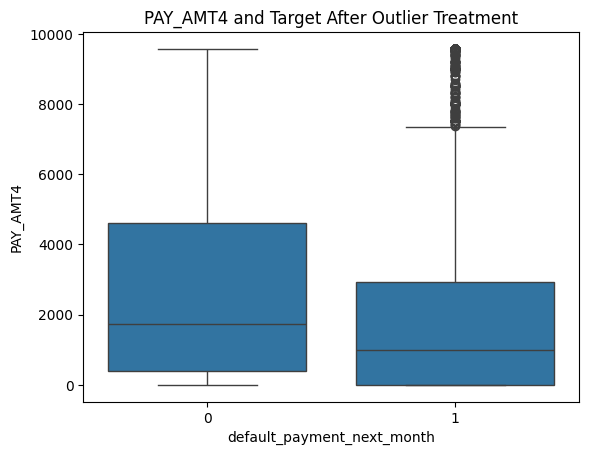

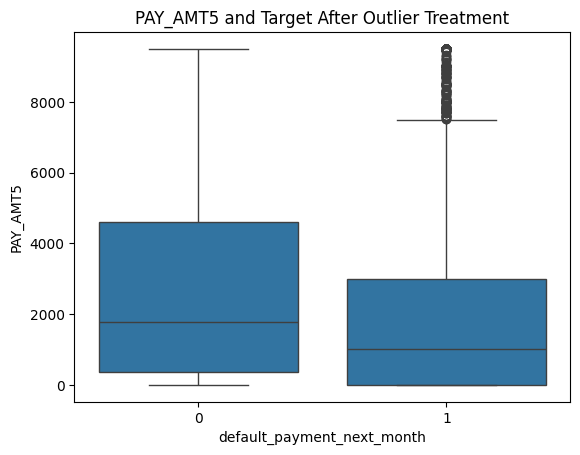

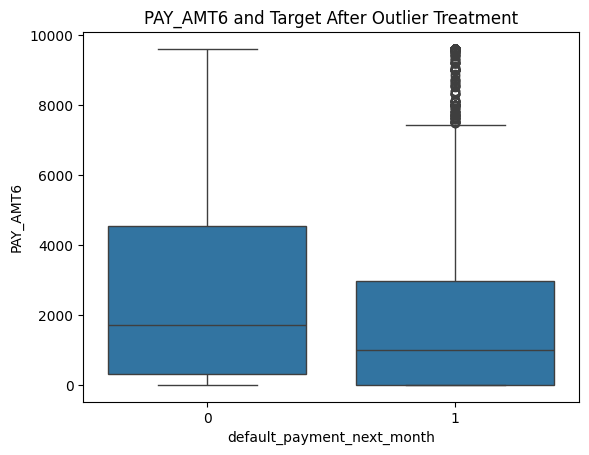

In [73]:
for f in ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']:
    treatment(f)

In [74]:
df.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000.0,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,10401.1,10000.0,9000.0,689.0,679.0,0


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  object 
 2   EDUCATION                   30000 non-null  object 
 3   MARRIAGE                    30000 non-null  object 
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

In [ ]:
# converting data types

In [76]:
df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','SEX','MARRIAGE','EDUCATION']]=df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','SEX','MARRIAGE','EDUCATION']].astype('category')

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   LIMIT_BAL                   30000 non-null  float64 
 1   SEX                         30000 non-null  category
 2   EDUCATION                   30000 non-null  category
 3   MARRIAGE                    30000 non-null  category
 4   AGE                         30000 non-null  int64   
 5   PAY_0                       30000 non-null  category
 6   PAY_2                       30000 non-null  category
 7   PAY_3                       30000 non-null  category
 8   PAY_4                       30000 non-null  category
 9   PAY_5                       30000 non-null  category
 10  PAY_6                       30000 non-null  category
 11  BILL_AMT1                   30000 non-null  float64 
 12  BILL_AMT2                   30000 non-null  float64 
 13  BILL_AMT3       

In [78]:
df[['LIMIT_BAL','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']]=df[['LIMIT_BAL','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']].astype('int')

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   LIMIT_BAL                   30000 non-null  int64   
 1   SEX                         30000 non-null  category
 2   EDUCATION                   30000 non-null  category
 3   MARRIAGE                    30000 non-null  category
 4   AGE                         30000 non-null  int64   
 5   PAY_0                       30000 non-null  category
 6   PAY_2                       30000 non-null  category
 7   PAY_3                       30000 non-null  category
 8   PAY_4                       30000 non-null  category
 9   PAY_5                       30000 non-null  category
 10  PAY_6                       30000 non-null  category
 11  BILL_AMT1                   30000 non-null  int64   
 12  BILL_AMT2                   30000 non-null  int64   
 13  BILL_AMT3       

In [80]:
df.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000,female,university,married,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,female,university,single,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,female,university,single,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,female,university,married,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,male,university,married,57,-1,0,-1,0,0,...,20940,19146,19131,2000,10401,10000,9000,689,679,0


In [ ]:
# pipeline with Encoding

In [81]:
cat_features = df.select_dtypes(include=['object','category']).columns.tolist()
cat_features                         

['SEX',
 'EDUCATION',
 'MARRIAGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6']

In [82]:
num_features = df.select_dtypes(include=['number']).columns.tolist()
num_features   


['LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default_payment_next_month']

In [83]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         cat_features),
        ('num', StandardScaler(),
         num_features)
    ]
)


In [84]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_features),
        ('num','passthrough',num_features)])


In [86]:
cat_preprocessor =  ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features)
    ]
)

In [131]:
models = {
    "Logistic": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )
}

In [111]:
X = df.drop(columns=[target])
y = df[target]

In [114]:
cat_features = ['SEX','EDUCATION','MARRIAGE','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
num_features = ['LIMIT_BAL','AGE','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
                'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']


In [ ]:
"XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [137]:
models = {
    "Logistic": LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42,
    ),
    "XGBoost": XGBClassifier(max_depth=2,gamma=10,colsample_bytree=0.4),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_state=42,
        verbose=0,
    ),
}


In [130]:
pipe = Pipeline([('preprocessor', linear_preprocessor),('model', model)])
pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [142]:
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, accuracy_score, precision_score, f1_score, confusion_matrix, classification_report
import pandas as pd

results = []

for name, model in models.items():
    
    # CatBoost requires separate fit with cat_features
    if name == 'CatBoost':
        pass
        #model.fit(X_train, y_train, cat_features=cat_feature_indices)
        #y_proba = model.predict_proba(X_test)[:, 1]
        #y_pred = model.predict(X_test)
        
    else:
        # Choose preprocessor
        if name == 'Logistic':
            preprocessor = linear_preprocessor
        else:
            preprocessor = tree_preprocessor
        
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        pipe.fit(X_train, y_train)
        y_train_proba = pipe.predict_proba(X_train)[:, 1]
        y_test_proba = pipe.predict_proba(X_test)[:, 1]

        train_score=roc_auc_score(y_train,y_train_proba)
        test_score=roc_auc_score(y_test,y_test_proba)
    
    results.append({
        "Model": name,
        "Train_ROC_AUC": train_score,
        "Test_ROC_AUC": test_score
    })

results_df = pd.DataFrame(results).sort_values("Test_ROC_AUC", ascending=False)
results_df


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 106
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639


,Model,Train_ROC_AUC,Test_ROC_AUC
0,Logistic,0.779003,0.765140
2,GradientBoosting,0.768297,0.749149
1,RandomForest,0.767579,0.747545
4,LightGBM,0.790998,0.746654
5,CatBoost,0.790998,0.746654
3,XGBoost,0.758810,0.745274


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

model.fit(X_train, y_train)


In [10]:
def feature_add(df):
    df_copy = df.copy()
    bill_columns = [col for col in df.columns if re.match("BILL_A",col)]
    payment_amount_columns = [col for col in df.columns if re.match('PAY_A',col)]
    df_copy['avg_bill_amount'] = df[bill_columns].mean(axis=1)
    df_copy['avg_payment_amount'] = df[payment_amount_columns].mean(axis=1)
    return df_copy

In [11]:
df = feature_add(df)
# creating new features called avg_bill_amount, avg_payment_amount

In [12]:
columns = df.columns.tolist()

In [13]:
print("Final DataSet Columns",columns)

Final DataSet Columns ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_payment_next_month', 'avg_bill_amount', 'avg_payment_amount']


###  Data moderatly imbalanced however there is no fix required as its not major cause

Text(0, 0.5, 'Count')

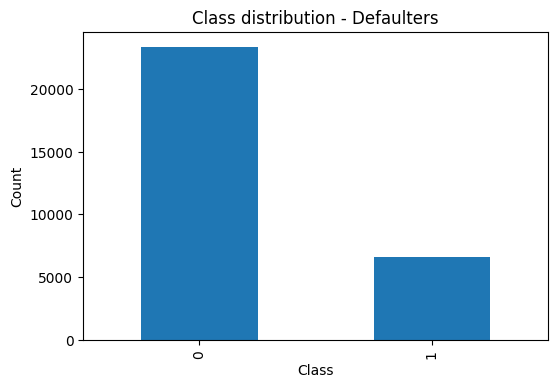

In [16]:
# Class distribution
class_counts = df[target].value_counts().sort_index()
ax = class_counts.plot(kind='bar', title='Class distribution - Defaulters', figsize=(6,4))
ax.set_xlabel('Class'); ax.set_ylabel('Count')

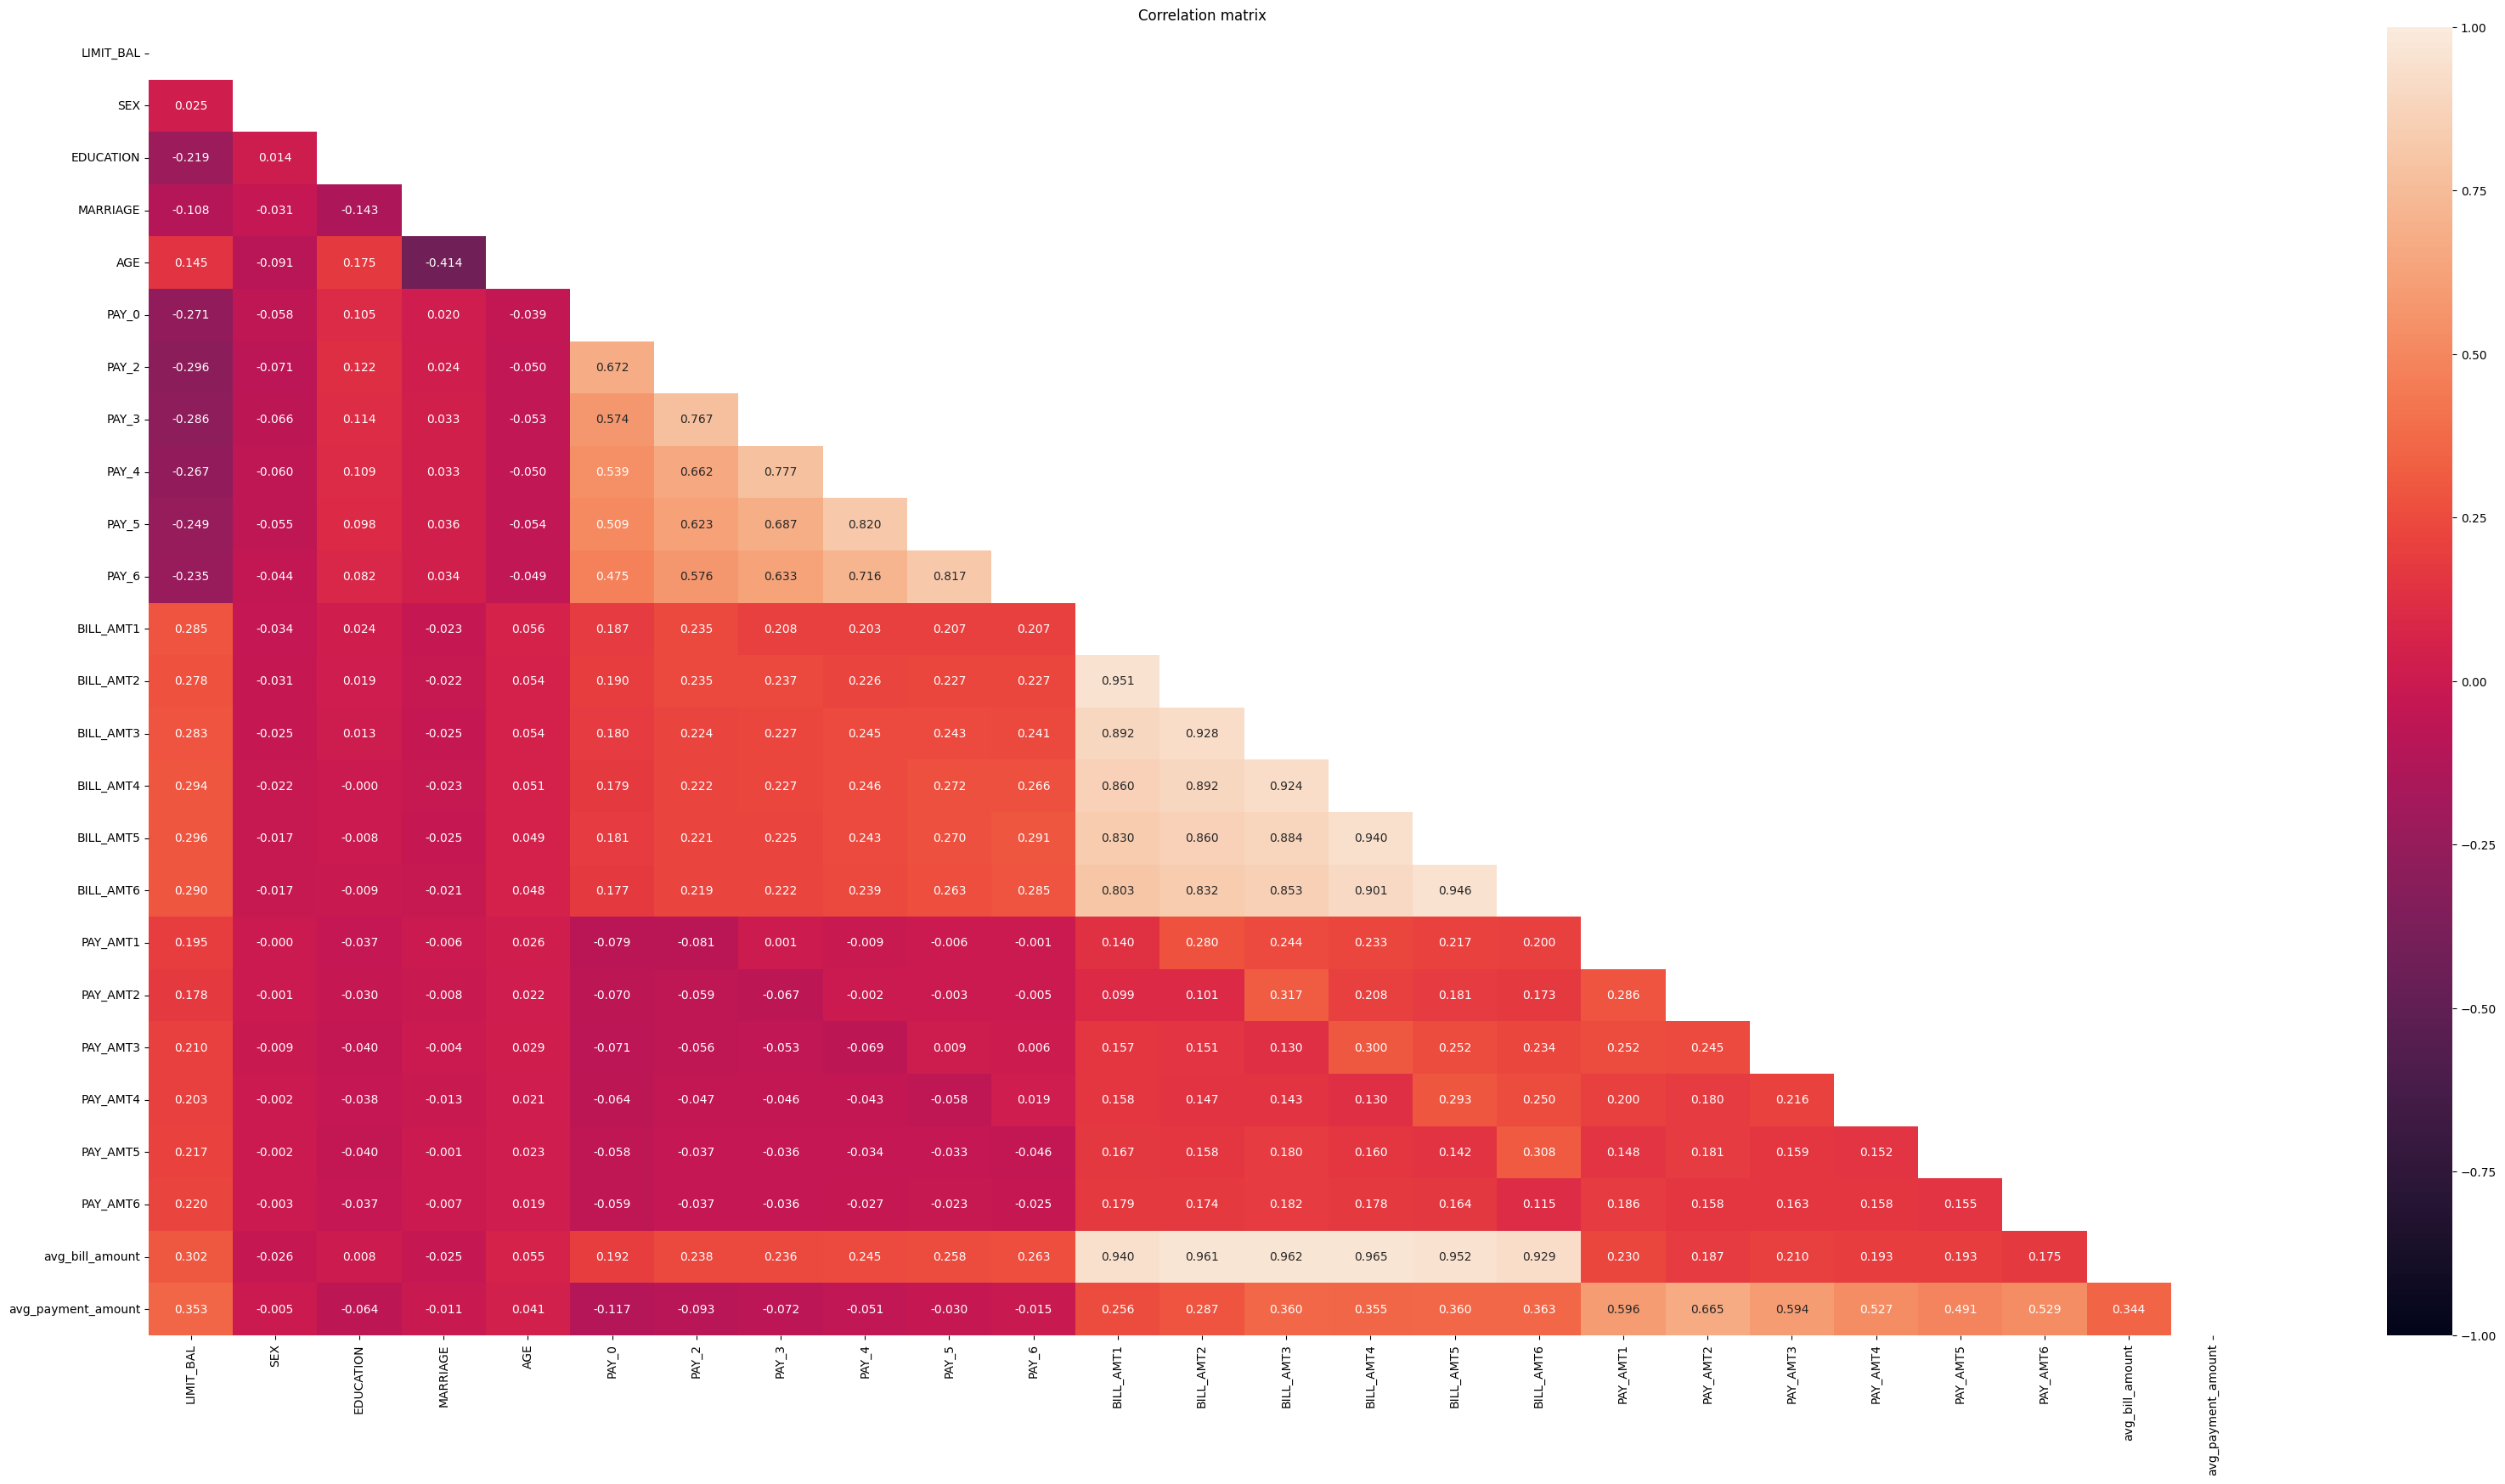

In [17]:
# Correlation Matrix
plt.figure(figsize=(40,20))
num_df = df.select_dtypes(include=[np.number]).drop(columns=target)
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Correlation matrix')
plt.show()

In [18]:
import pandas as pd
import numpy as np

# Correlation matrix
corr_matrix = df.corr().abs()

# Upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation > 0.9
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Columns to consider dropping:", to_drop)


Columns to consider dropping: ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'avg_bill_amount']


## Decision

 Though BILL_AMT2 to BILL_AMT6 and avg_bill_amount are highely correlated to other features, we are not dropping those considering the relationship it hold on the Pay and Pay Amount Features

In [19]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month,avg_bill_amount,avg_payment_amount
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1284.000000,114.833333
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,2846.166667,833.333333
2,90000.0,2,2,2,34,0,0,0,0,0,...,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,16942.166667,1836.333333
3,50000.0,2,2,1,37,0,0,0,0,0,...,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,38555.666667,1398.000000
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,18223.166667,9841.500000


In [20]:
unique_counts_per_columns = {}
for col in columns:
    unique_counts_per_columns[col] = df[col].value_counts().shape[0]

In [21]:
unq_cnt_df = pd.DataFrame( unique_counts_per_columns, ["unique_counts_column"]).transpose()

In [22]:
unq_cnt_df
# find unique values counts in each feature

,unique_counts_column
LIMIT_BAL,81
SEX,2
EDUCATION,7
MARRIAGE,4
AGE,56
PAY_0,11
PAY_2,11
PAY_3,11
PAY_4,11
PAY_5,10


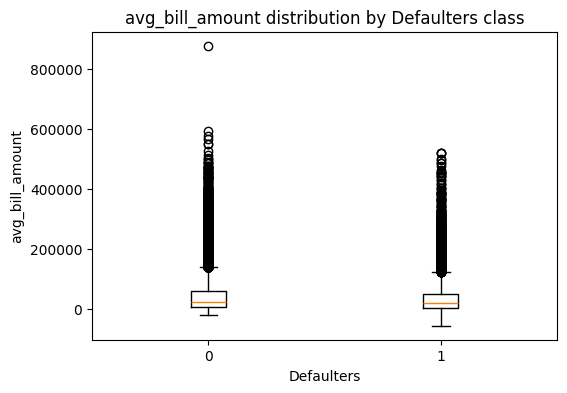

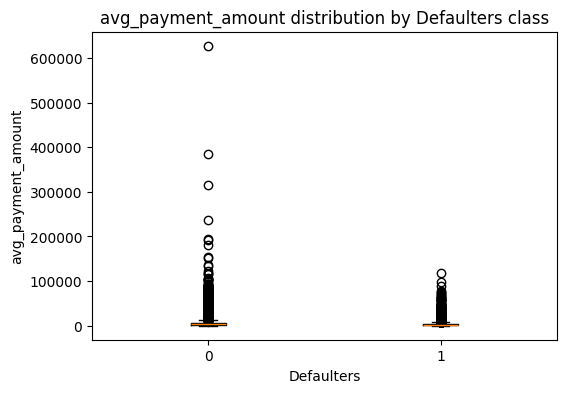

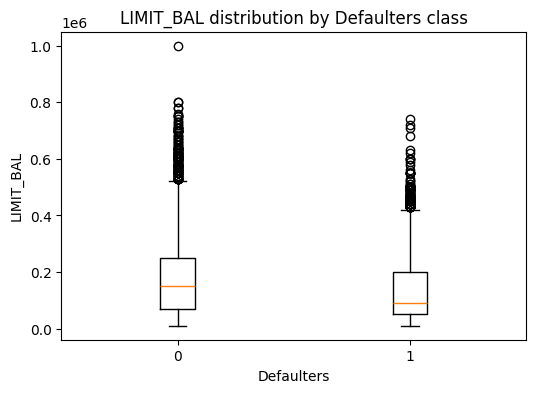

In [23]:
# Boxplots for key continuous features by class
key_features = ['avg_bill_amount', 'avg_payment_amount', 'LIMIT_BAL', 'Age']
for feat in key_features:
    if feat in df.columns:
        plt.figure(figsize=(6,4))
        data_to_plot = [df.loc[df[target]==cls, feat].dropna() for cls in sorted(df[target].unique())]
        plt.boxplot(data_to_plot, tick_labels=[str(x) for x in sorted(df[target].unique())])
        plt.title(f"{feat} distribution by Defaulters class")
        plt.xlabel("Defaulters")
        plt.ylabel(feat)
        plt.show()

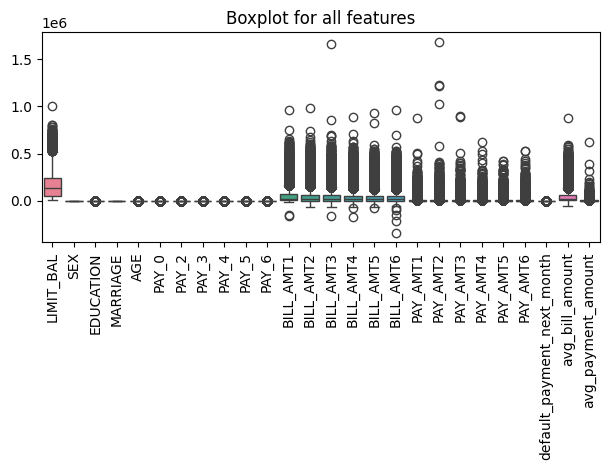

In [24]:
sns.boxplot(data=df)
plt.title("Boxplot for all features")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [25]:
num_features = [
    'LIMIT_BAL', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6','avg_bill_amount','avg_payment_amount'
]
 # Numeric Features

In [26]:
cat_features = ['SEX', 'EDUCATION', 'MARRIAGE']
# Categorical Features

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ]
)


## Model Selection Split,  Training and Performance 

In [28]:
X = df.drop(columns=[target])
y = df[target].astype(int)

In [29]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'avg_bill_amount', 'avg_payment_amount'],
      dtype='object')

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [35]:
models = {
    "Logistic": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_state=42,
        verbose=0
    )
}

In [40]:
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score
import pandas as pd

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "PR_AUC": average_precision_score(y_test, y_proba),
        "Recall": recall_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Classification Report": classification_report(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
results_df

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003671 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3786
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639


,Model,ROC_AUC,PR_AUC,Recall,Accuracy,Precision,F1-score,ROC-AUC,Confusion Matrix,Classification Report
2,GradientBoosting,0.780218,0.558287,0.368500,0.817833,0.657258,0.472236,0.656966,"[[4418, 255], [838, 489]]",precision recall f1-score ...
5,CatBoost,0.779625,0.557592,0.360211,0.816167,0.653005,0.464303,0.652928,"[[4419, 254], [849, 478]]",precision recall f1-score ...
3,XGBoost,0.777719,0.554359,0.366993,0.818500,0.661685,0.472128,0.656854,"[[4424, 249], [840, 487]]",precision recall f1-score ...
1,RandomForest,0.777622,0.555772,0.348154,0.816167,0.660000,0.455846,0.648611,"[[4435, 238], [865, 462]]",precision recall f1-score ...
4,LightGBM,0.776600,0.553100,0.363225,0.819167,0.667590,0.470473,0.655933,"[[4433, 240], [845, 482]]",precision recall f1-score ...
0,Logistic,0.710408,0.490922,0.630746,0.678000,0.367266,0.464226,0.661082,"[[3231, 1442], [490, 837]]",precision recall f1-score ...


In [44]:
confirmed_model=GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42)

In [45]:
confirmed_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', confirmed_model)])

In [46]:
confirmed_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
y_proba = confirmed_pipe.predict_proba(X_test)[:, 1]

In [48]:
y_pred = confirmed_pipe.predict(X_test)

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get trained Gradient Boosting model
gb_model = models["GradientBoosting"]

# (Optional) Fit only if not already fitted
# gb_model.fit(X_train, y_train)

# Extract feature importance
feature_importance = gb_model.feature_importances_

fi_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": feature_importance
    })
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

fi_df.head(10)


,feature,importance
0,PAY_0,0.549448
1,PAY_2,0.070878
2,PAY_3,0.042738
3,avg_payment_amount,0.038823
4,LIMIT_BAL,0.035133
5,BILL_AMT1,0.030507
6,avg_bill_amount,0.027693
7,PAY_4,0.022049
8,PAY_5,0.018288
9,PAY_6,0.016832


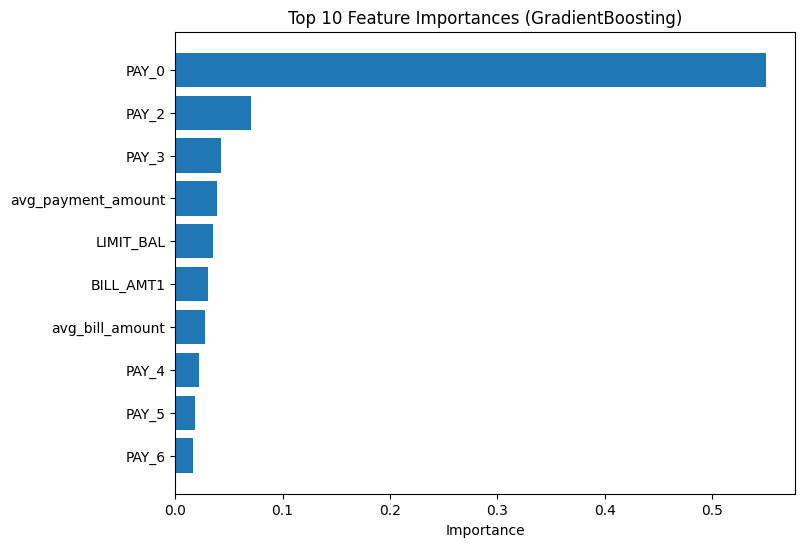

In [56]:
plt.figure(figsize=(8,6))
plt.barh(fi_df["feature"].head(10)[::-1], fi_df["importance"].head(10)[::-1])
plt.title("Top 10 Feature Importances (GradientBoosting)")
plt.xlabel("Importance")
plt.show()

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve

# Train baseline again
baseline = LogisticRegression(max_iter=2000, random_state=42)
baseline.fit(X_train, y_train)

y_proba_base = baseline.predict_proba(X_test)[:, 1]

prec_b, rec_b, thr_b = precision_recall_curve(y_test, y_proba_base)

# Find threshold closest to recall = 0.80
target_recall = 0.80
idx_base = (abs(rec_b - target_recall)).argmin()
baseline_threshold = thr_b[idx_base]


In [58]:
from sklearn.metrics import classification_report

y_base_final = (y_proba_base >= baseline_threshold).astype(int)

print("Baseline threshold:", baseline_threshold)
print(classification_report(y_test, y_base_final))

Baseline threshold: 0.14237381653812015
              precision    recall  f1-score   support

           0       0.87      0.37      0.52      4673
           1       0.27      0.80      0.40      1327

    accuracy                           0.47      6000
   macro avg       0.57      0.59      0.46      6000
weighted avg       0.74      0.47      0.50      6000



In [60]:
import joblib

final_artifact = {
    "model": gb_model,              # trained gb_model model
    "threshold": 0.14237381653812015,   # chosen threshold
    "features": X_train.columns.tolist()
}

joblib.dump(final_artifact, "../cc_defaulter_model.pkl")

['cc_defaulter_model.pkl']

In [62]:
import pickle

In [63]:
with open('../model/bank_cc_defaults_model.pkl', 'wb') as f:
    pickle.dump(gb_model, f)   